# 3D k-Wave: Cube Skull Test
Hollow cube skull (bone) surrounding a brain interior, single pressure source at center.
Geometry uses L-inf (Chebyshev) distance so isocontours are cubes.

| Layer | c (m/s) | rho (kg/m^3) |
|-------|---------|----------|
| Water (outside) | 1482 | 1000 |
| Skull (bone)    | 2900 | 1900 |
| Brain (inside)  | 1560 | 1040 |

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

c:\Users\bengi\miniconda3\envs\pesaranlab\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## Cube Skull

### Parameters

In [2]:
# Acoustic parameters (matching 2D notebook conventions)
freq       = 500e3       # 500 kHz

c_water    = 1482.0;  rho_water  = 1000.0
c_skull    = 2900.0;  rho_skull  = 1900.0
c_brain    = 1560.0;  rho_brain  = 1040.0

# Grid: 6 points per wavelength
wavelength = c_water / freq
dx         = wavelength / 6

# 128^3 grid -> ~63 mm cube, comfortable on GPU
N          = 128
Nx = Ny = Nz = N

print(f'Wavelength : {wavelength*1e3:.2f} mm')
print(f'Grid step  : {dx*1e3:.3f} mm')
print(f'Domain     : {N*dx*1e3:.1f} mm per side  ({N}^3 points)')

Wavelength : 2.96 mm
Grid step  : 0.494 mm
Domain     : 63.2 mm per side  (128^3 points)


### Make the volume

In [3]:
kgrid = kWaveGrid([Nx, Ny, Nz], [dx, dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)

print(f'dt    = {kgrid.dt:.3e} s')
print(f'Nt    = {kgrid.Nt}')
print(f't_end = {kgrid.Nt * kgrid.dt * 1e6:.1f} us')

dt    = 5.110e-08 s
Nt    = 740
t_end = 37.8 us


In [4]:
# Geometry: hollow cube skull
cx = cy = cz = N // 2

brain_half_mm  = 20.0   # inner half-side (brain surface), mm
skull_thick_mm =  3.0   # skull wall thickness, mm

brain_half_px  = brain_half_mm                    * 1e-3 / dx
skull_outer_px = (brain_half_mm + skull_thick_mm) * 1e-3 / dx

print(f'Brain half-side : {brain_half_mm:.1f} mm  ({brain_half_px:.1f} px)')
print(f'Skull outer half: {brain_half_mm + skull_thick_mm:.1f} mm  ({skull_outer_px:.1f} px)')
print(f'Water padding   : {(N/2 - skull_outer_px) * dx * 1e3:.1f} mm each side')

# L-inf distance from center -> cube isocontours
II, JJ, KK = np.meshgrid(
    np.arange(Nx) - cx,
    np.arange(Ny) - cy,
    np.arange(Nz) - cz,
    indexing='ij'
)
L_inf = np.maximum(np.maximum(np.abs(II), np.abs(JJ)), np.abs(KK))

brain_mask = L_inf <  brain_half_px
skull_mask = (L_inf >= brain_half_px) & (L_inf < skull_outer_px)

print(f'Brain voxels: {brain_mask.sum():,}')
print(f'Skull voxels: {skull_mask.sum():,}')

Brain half-side : 20.0 mm  (40.5 px)
Skull outer half: 23.0 mm  (46.6 px)
Water padding   : 8.6 mm each side
Brain voxels: 531,441
Skull voxels: 272,916


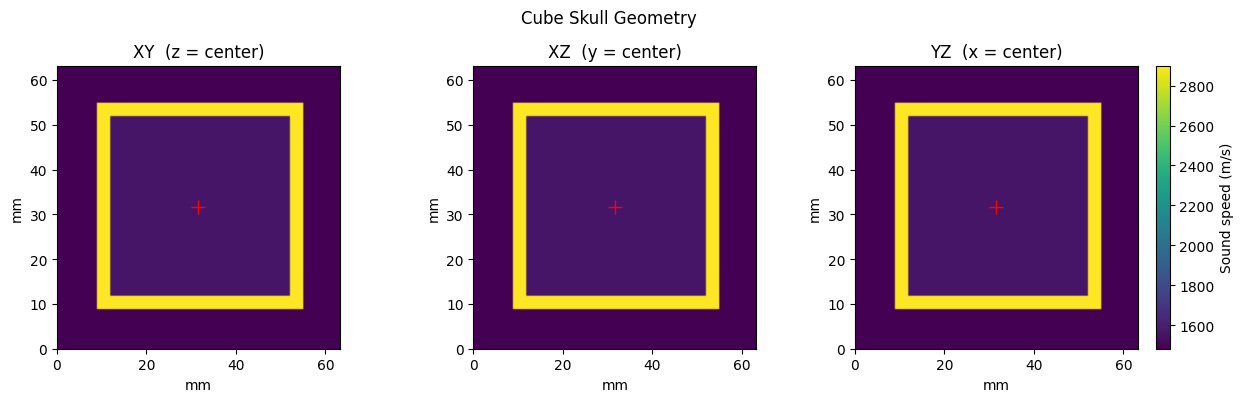

In [5]:
# Build heterogeneous medium
sound_speed_map = np.full((Nx, Ny, Nz), c_water,   dtype=np.float32)
density_map     = np.full((Nx, Ny, Nz), rho_water, dtype=np.float32)

sound_speed_map[skull_mask] = c_skull;  density_map[skull_mask] = rho_skull
sound_speed_map[brain_mask] = c_brain;  density_map[brain_mask] = rho_brain

medium = kWaveMedium(sound_speed=sound_speed_map, density=density_map)

# Geometry sanity check
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(origin='lower', cmap='viridis', vmin=c_water, vmax=c_skull,
          extent=[0, N*dx*1e3, 0, N*dx*1e3])

axes[0].imshow(sound_speed_map[:, :, cz].T, **kw)
axes[0].set_title('XY  (z = center)')
axes[1].imshow(sound_speed_map[:, cy, :].T, **kw)
axes[1].set_title('XZ  (y = center)')
im = axes[2].imshow(sound_speed_map[cx, :, :].T, **kw)
axes[2].set_title('YZ  (x = center)')

for ax in axes:
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(cx*dx*1e3, cy*dx*1e3, 'r+', ms=10)

plt.colorbar(im, ax=axes[2], label='Sound speed (m/s)')
plt.suptitle('Cube Skull Geometry')
plt.tight_layout()
plt.show()

In [6]:
# Source: single point at center, 100 kPa tone burst
source = kSource()
source.p_mask = np.zeros((Nx, Ny, Nz), dtype=np.uint8)
source.p_mask[cx, cy, cz] = 1

burst    = tone_burst(1 / kgrid.dt, freq, 5).flatten()
source.p = (burst * 1e5).reshape(1, -1)

# Sensor: full-volume p_max
sensor = kSensor()
sensor.mask   = np.ones((Nx, Ny, Nz), dtype=np.uint8)
sensor.record = ['p_max']

print(f'Source : point at ({cx}, {cy}, {cz})')
print(f'Burst  : {len(burst)} samples, amplitude 100 kPa')

Source : point at (64, 64, 64)
Burst  : 196 samples, amplitude 100 kPa


In [7]:
print('Running 3D k-Wave on GPU ...')
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor,
                               device='gpu', dtype='float32')

p_max = sensor_data['p_max'].reshape(Nx, Ny, Nz)

if np.isnan(p_max).any():
    print('WARNING: NaN in output')
else:
    print('Simulation OK')
    print(f'Peak pressure overall : {np.max(p_max)/1e3:.1f} kPa')
    print(f'Peak pressure in brain: {np.max(p_max[brain_mask])/1e3:.1f} kPa')

Running 3D k-Wave on GPU ...


k-Wave: 100%|██████████| 740/740 [00:17<00:00, 41.26step/s]


Simulation OK
Peak pressure overall : 33.2 kPa
Peak pressure in brain: 33.2 kPa


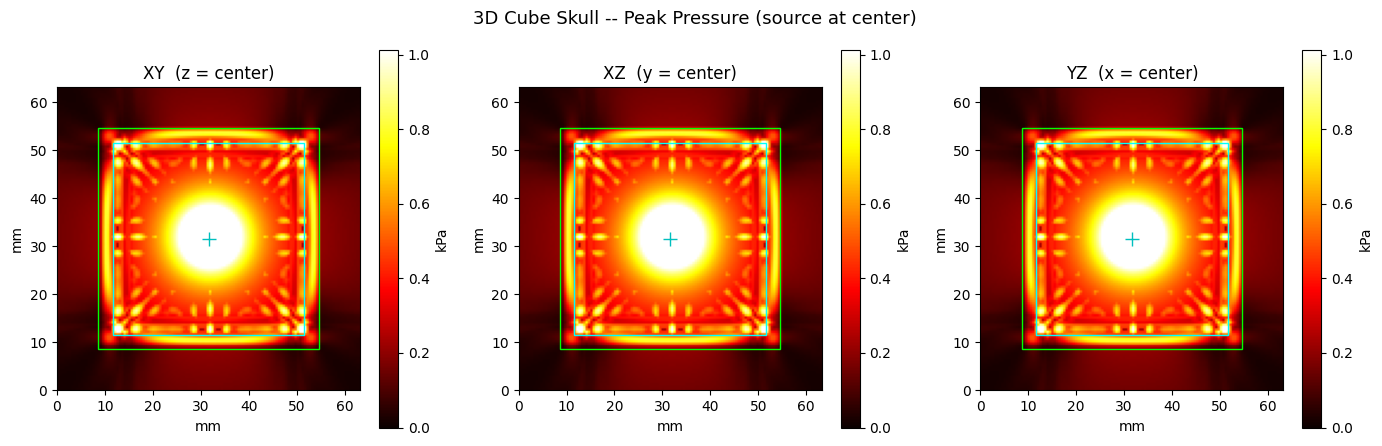

Saved to 3d_cube_skull_pmax.png


In [8]:
# Visualise: three orthogonal p_max slices
vmax_kpa = np.percentile(p_max, 99.5) / 1e3
extent_mm = [0, N*dx*1e3, 0, N*dx*1e3]

slices = [
    (p_max[:, :, cz].T / 1e3, 'XY  (z = center)'),
    (p_max[:, cy, :].T / 1e3, 'XZ  (y = center)'),
    (p_max[cx, :, :].T / 1e3, 'YZ  (x = center)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (data, title) in zip(axes, slices):
    im = ax.imshow(data, origin='lower', extent=extent_mm,
                   cmap='hot', vmin=0, vmax=vmax_kpa)
    ax.set_title(title)
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=10)
    plt.colorbar(im, ax=ax, label='kPa')
    # skull boundary rectangles
    for r_mm, color in [(brain_half_mm, 'cyan'),
                        (brain_half_mm + skull_thick_mm, 'lime')]:
        c_mm = cx * dx * 1e3
        rect = plt.Rectangle((c_mm - r_mm, c_mm - r_mm), 2*r_mm, 2*r_mm,
                              lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

plt.suptitle('3D Cube Skull -- Peak Pressure (source at center)', fontsize=13)
plt.tight_layout()
plt.savefig('3d_cube_skull_pmax.png', dpi=150)
plt.show()
print('Saved to 3d_cube_skull_pmax.png')

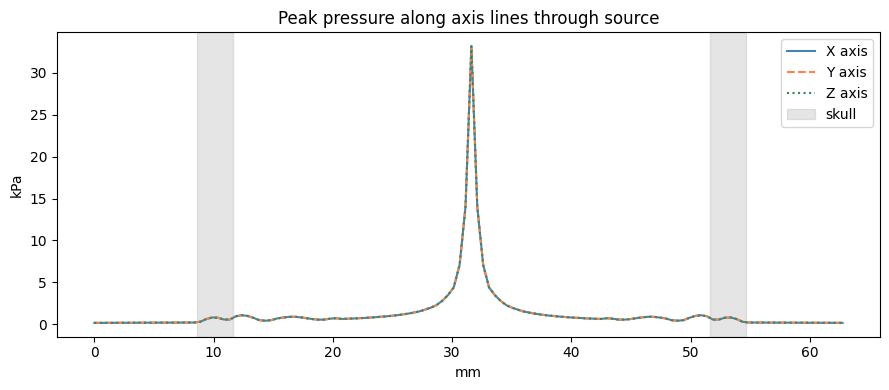

In [9]:
# 1-D pressure profiles along each axis through center
x_mm = np.arange(N) * dx * 1e3
c_mm = cx * dx * 1e3

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_mm, p_max[:, cy, cz] / 1e3, label='X axis', color='steelblue')
ax.plot(x_mm, p_max[cx, :, cz] / 1e3, label='Y axis', color='coral',   ls='--')
ax.plot(x_mm, p_max[cx, cy, :] / 1e3, label='Z axis', color='seagreen', ls=':')

# shade skull walls
for sign in [-1, 1]:
    lo = c_mm + sign * (brain_half_mm + skull_thick_mm)
    hi = c_mm + sign * brain_half_mm
    ax.axvspan(min(lo, hi), max(lo, hi), alpha=0.2, color='gray',
               label='skull' if sign == 1 else None)

ax.set_xlabel('mm')
ax.set_ylabel('kPa')
ax.set_title('Peak pressure along axis lines through source')
ax.legend()
plt.tight_layout()
plt.show()

## Sphere Skull
Same grid, source, and sensor as the cube test -- only the geometry changes.  
Geometry uses L2 (Euclidean) distance from center, so isocontours are spheres.

In [10]:
# Sphere skull geometry (reuse II, JJ, KK meshgrid arrays from cube section)
brain_radius_mm  = 20.0   # inner sphere radius (brain surface), mm
skull_thick_mm_s =  3.0   # skull wall thickness, mm

brain_radius_px  = brain_radius_mm                        * 1e-3 / dx
skull_outer_px_s = (brain_radius_mm + skull_thick_mm_s)   * 1e-3 / dx

# Euclidean (L2) distance from center -> sphere isocontours
R = np.sqrt(II**2 + JJ**2 + KK**2)

brain_mask_sph = R <  brain_radius_px
skull_mask_sph = (R >= brain_radius_px) & (R < skull_outer_px_s)

print(f'Brain radius : {brain_radius_mm:.1f} mm  ({brain_radius_px:.1f} px)')
print(f'Skull outer  : {brain_radius_mm + skull_thick_mm_s:.1f} mm  ({skull_outer_px_s:.1f} px)')
print(f'Water padding: {(N/2 - skull_outer_px_s) * dx * 1e3:.1f} mm each side')
print(f'Brain voxels : {brain_mask_sph.sum():,}')
print(f'Skull voxels : {skull_mask_sph.sum():,}')

Brain radius : 20.0 mm  (40.5 px)
Skull outer  : 23.0 mm  (46.6 px)
Water padding: 8.6 mm each side
Brain voxels : 278,177
Skull voxels : 144,324


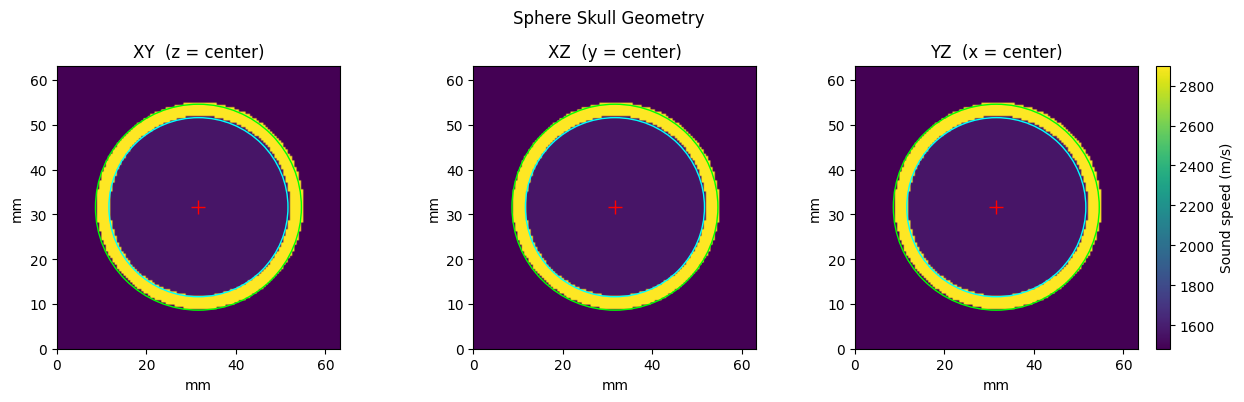

In [11]:
sound_speed_sph = np.full((Nx, Ny, Nz), c_water,   dtype=np.float32)
density_sph     = np.full((Nx, Ny, Nz), rho_water, dtype=np.float32)

sound_speed_sph[skull_mask_sph] = c_skull;  density_sph[skull_mask_sph] = rho_skull
sound_speed_sph[brain_mask_sph] = c_brain;  density_sph[brain_mask_sph] = rho_brain

medium_sph = kWaveMedium(sound_speed=sound_speed_sph, density=density_sph)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(origin='lower', cmap='viridis', vmin=c_water, vmax=c_skull,
          extent=[0, N*dx*1e3, 0, N*dx*1e3])
axes[0].imshow(sound_speed_sph[:, :, cz].T, **kw)
axes[0].set_title('XY  (z = center)')
axes[1].imshow(sound_speed_sph[:, cy, :].T, **kw)
axes[1].set_title('XZ  (y = center)')
im = axes[2].imshow(sound_speed_sph[cx, :, :].T, **kw)
axes[2].set_title('YZ  (x = center)')

c_mm = cx * dx * 1e3
for ax in axes:
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(c_mm, c_mm, 'r+', ms=10)
    for r_mm, color in [(brain_radius_mm, 'cyan'),
                        (brain_radius_mm + skull_thick_mm_s, 'lime')]:
        circle = plt.Circle((c_mm, c_mm), r_mm, lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(circle)

plt.colorbar(im, ax=axes[2], label='Sound speed (m/s)')
plt.suptitle('Sphere Skull Geometry')
plt.tight_layout()
plt.show()

In [12]:
# Source and sensor are identical to the cube test (point at center, full-volume p_max)
print('Running sphere skull on GPU ...')
sensor_data_sph = kspaceFirstOrder(kgrid, medium_sph, source, sensor,
                                   device='gpu', dtype='float32')

p_max_sph = sensor_data_sph['p_max'].reshape(Nx, Ny, Nz)

if np.isnan(p_max_sph).any():
    print('WARNING: NaN in output')
else:
    print('Simulation OK')
    print(f'Peak pressure overall : {np.max(p_max_sph)/1e3:.1f} kPa')
    print(f'Peak pressure in brain: {np.max(p_max_sph[brain_mask_sph])/1e3:.1f} kPa')

Running sphere skull on GPU ...


k-Wave: 100%|██████████| 740/740 [00:17<00:00, 42.67step/s]


Simulation OK
Peak pressure overall : 33.2 kPa
Peak pressure in brain: 33.2 kPa


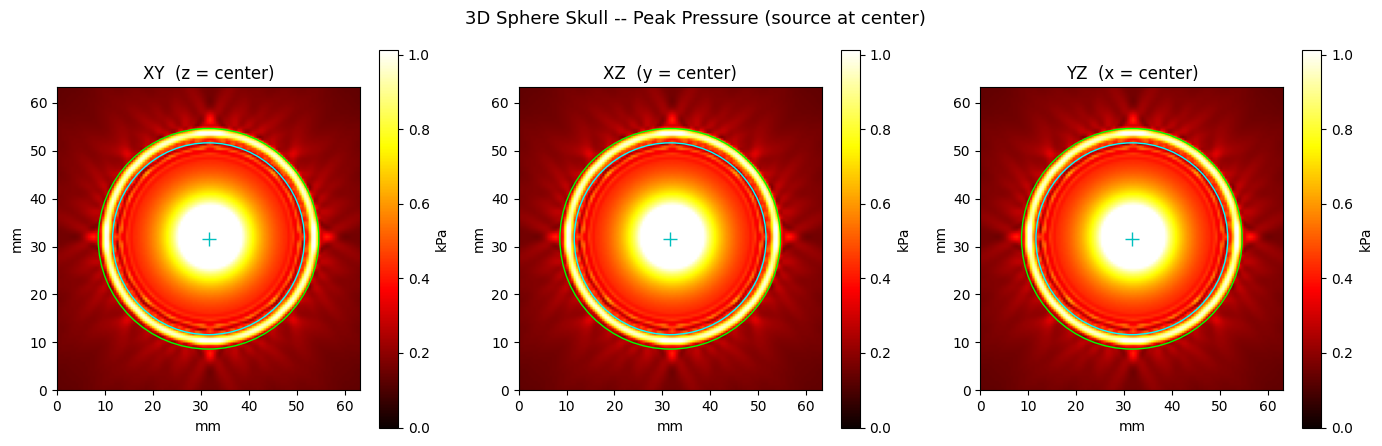

Saved to 3d_sphere_skull_pmax.png


In [13]:
vmax_kpa_s = np.percentile(p_max_sph, 99.5) / 1e3
extent_mm = [0, N*dx*1e3, 0, N*dx*1e3]

slices = [
    (p_max_sph[:, :, cz].T / 1e3, 'XY  (z = center)'),
    (p_max_sph[:, cy, :].T / 1e3, 'XZ  (y = center)'),
    (p_max_sph[cx, :, :].T / 1e3, 'YZ  (x = center)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
c_mm = cx * dx * 1e3
for ax, (data, title) in zip(axes, slices):
    im = ax.imshow(data, origin='lower', extent=extent_mm,
                   cmap='hot', vmin=0, vmax=vmax_kpa_s)
    ax.set_title(title)
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
    ax.plot(c_mm, c_mm, 'c+', ms=10)
    plt.colorbar(im, ax=ax, label='kPa')
    for r_mm, color in [(brain_radius_mm, 'cyan'),
                        (brain_radius_mm + skull_thick_mm_s, 'lime')]:
        circle = plt.Circle((c_mm, c_mm), r_mm, lw=1, edgecolor=color, facecolor='none')
        ax.add_patch(circle)

plt.suptitle('3D Sphere Skull -- Peak Pressure (source at center)', fontsize=13)
plt.tight_layout()
plt.savefig('3d_sphere_skull_pmax.png', dpi=150)
plt.show()
print('Saved to 3d_sphere_skull_pmax.png')

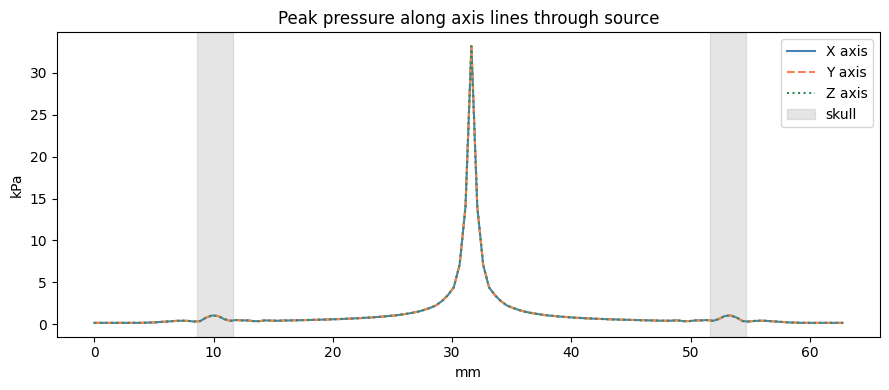

In [14]:
x_mm = np.arange(N) * dx * 1e3
c_mm = cx * dx * 1e3

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_mm, p_max_sph[:, cy, cz] / 1e3, label='X axis', color='steelblue')
ax.plot(x_mm, p_max_sph[cx, :, cz] / 1e3, label='Y axis', color='coral',   ls='--')
ax.plot(x_mm, p_max_sph[cx, cy, :] / 1e3, label='Z axis', color='seagreen', ls=':')

for sign in [-1, 1]:
    lo = c_mm + sign * (brain_radius_mm + skull_thick_mm_s)
    hi = c_mm + sign * brain_radius_mm
    ax.axvspan(min(lo, hi), max(lo, hi), alpha=0.2, color='gray',
               label='skull' if sign == 1 else None)

ax.set_xlabel('mm')
ax.set_ylabel('kPa')
ax.set_title('Peak pressure along axis lines through source')
ax.legend()
plt.tight_layout()
plt.show()